<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Final Assignment</center></h1>


> ***Note: Please ensure you follow the instructions outlined in the in the <a href="https://www.coursera.org/learn/supervised-machine-learning-regression/supplement/YGZt9/project-scenario">Project Scenario</a> section to complete this Final Assignment successfully.***


In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 134.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 81.0 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Write your code here or you can add this a markdown cell.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/Ames_Housing_Sales.csv"
df = pd.read_csv(data_url)

print(f"Dataset Dimensional Layout: {df.shape[0]} Observations, {df.shape[1]} Columns\n")
print("Target Variable Information summary:")
print(df['SalePrice'].describe())

Dataset Dimensional Layout: 1379 Observations, 80 Columns

Target Variable Information summary:
count      1379.00000
mean     185479.51124
std       79023.89060
min       35311.00000
25%      134000.00000
50%      167500.00000
75%      217750.00000
max      755000.00000
Name: SalePrice, dtype: float64


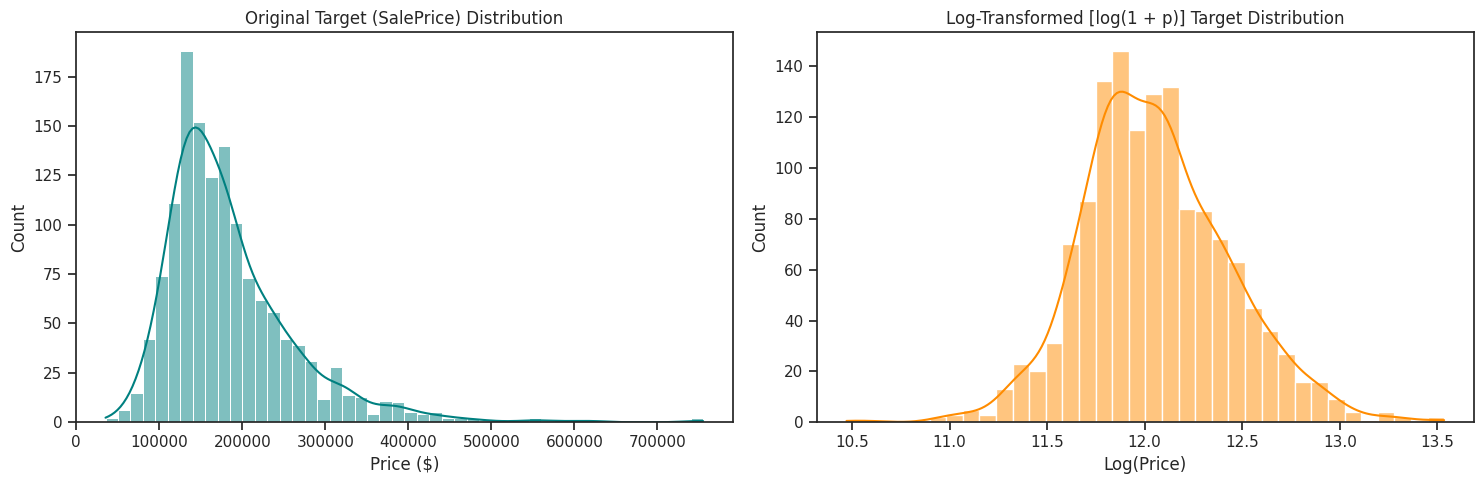

In [9]:
# Write your code here or you can add this a markdown cell.
sns.set_theme(style='ticks', context='notebook', palette='muted')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Original Target (SalePrice) Distribution')
axes[0].set_xlabel('Price ($)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Log-Transformed [log(1 + p)] Target Distribution')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

In [10]:
# Write your code here or you can add this a markdown cell.
X = df.drop(columns=['SalePrice'])
y = np.log1p(df['SalePrice'])

X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Feature matrix dimensions after complete One-Hot Encoding: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Feature matrix dimensions after complete One-Hot Encoding: (1379, 240)


In [11]:
# Write your code here or you can add this a markdown cell.
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

y_train_pred_ols = ols_model.predict(X_train_scaled)
y_test_pred_ols = ols_model.predict(X_test_scaled)

ols_train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_ols)))
ols_test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_ols)))
ols_train_r2 = r2_score(y_train, y_train_pred_ols)
ols_test_r2 = r2_score(y_test, y_test_pred_ols)

print(" Model 1: OLS Baseline Summary")
print(f"Training Data - RMSE: ${ols_train_rmse:,.2f} | R²: {ols_train_r2:.4f}")
print(f"Testing Data  - RMSE: ${ols_test_rmse:,.2f} | R²: {ols_test_r2:.4f}")

 Model 1: OLS Baseline Summary
Training Data - RMSE: $14,776.90 | R²: 0.9628
Testing Data  - RMSE: $45,347.96 | R²: 0.5798


In [12]:
# Write your code here or you can add this a markdown cell.
alphas_ridge = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge_cv.predict(X_train_scaled)
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)

ridge_train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_ridge)))
ridge_test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_ridge)))
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

print("Model 2: Ridge Regression Summary")
print(f"Optimal Alpha Selected: {ridge_cv.alpha_:.4f}")
print(f"Training Data - RMSE: ${ridge_train_rmse:,.2f} | R²: {ridge_train_r2:.4f}")
print(f"Testing Data  - RMSE: ${ridge_test_rmse:,.2f} | R²: {ridge_test_r2:.4f}")

Model 2: Ridge Regression Summary
Optimal Alpha Selected: 215.4435
Training Data - RMSE: $18,340.58 | R²: 0.9470
Testing Data  - RMSE: $37,485.37 | R²: 0.7343


In [13]:
lasso_cv = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
y_test_pred_lasso = lasso_cv.predict(X_test_scaled)

lasso_train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred_lasso)))
lasso_test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_test_pred_lasso)))
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)

total_features = X_train_scaled.shape[1]
active_features = np.sum(lasso_cv.coef_ != 0)

print("Model 3: Lasso Regression Summary")
print(f"Optimal Alpha Selected: {lasso_cv.alpha_:.6f}")
print(f"Feature Selection: Maintained {active_features} columns out of {total_features}")
print(f"Training Data - RMSE: ${lasso_train_rmse:,.2f} | R²: {lasso_train_r2:.4f}")
print(f"Testing Data  - RMSE: ${lasso_test_rmse:,.2f} | R²: {lasso_test_r2:.4f}")

Model 3: Lasso Regression Summary
Optimal Alpha Selected: 0.002182
Feature Selection: Maintained 124 columns out of 240
Training Data - RMSE: $16,619.89 | R²: 0.9503
Testing Data  - RMSE: $45,712.09 | R²: 0.5919


,Baseline OLS,Ridge (L2),Lasso (L1)
Metric Name,,,
Train RMSE ($),14776.9029,18340.5759,16619.8888
Test RMSE ($),45347.9565,37485.3734,45712.0888
Train R²,0.9628,0.9470,0.9503
Test R²,0.5798,0.7343,0.5919


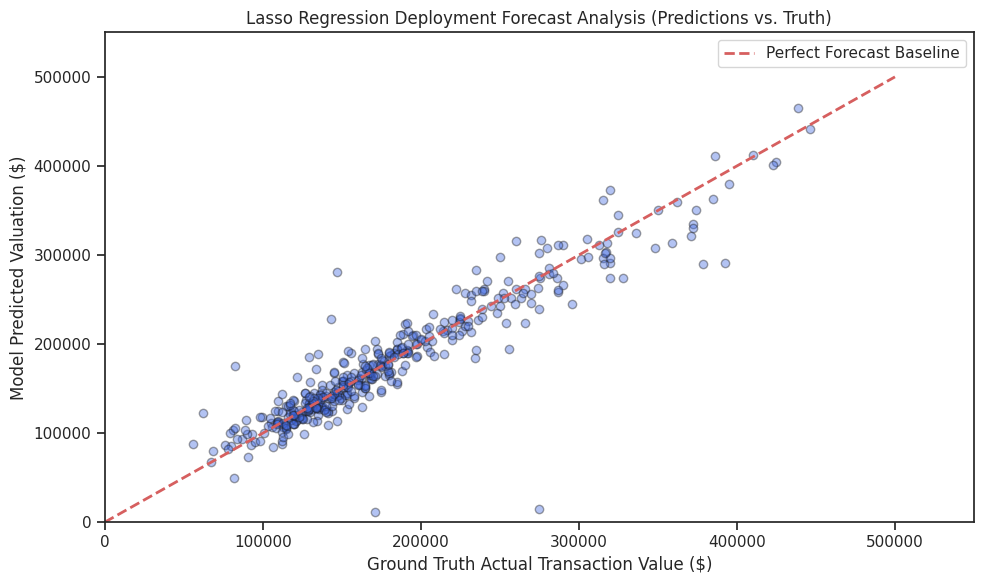

In [14]:
comparison_metrics = {
    'Metric Name': ['Train RMSE ($)', 'Test RMSE ($)', 'Train R²', 'Test R²'],
    'Baseline OLS': [ols_train_rmse, ols_test_rmse, ols_train_r2, ols_test_r2],
    'Ridge (L2)': [ridge_train_rmse, ridge_test_rmse, ridge_train_r2, ridge_test_r2],
    'Lasso (L1)': [lasso_train_rmse, lasso_test_rmse, lasso_train_r2, lasso_test_r2]
}

df_comparison = pd.DataFrame(comparison_metrics).set_index('Metric Name')
display(df_comparison.round(4))

plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_test_pred_lasso), alpha=0.4, color='royalblue', edgecolors='k')
plt.plot([0, 500000], [0, 500000], '--r', linewidth=2, label="Perfect Forecast Baseline")

plt.xlabel('Ground Truth Actual Transaction Value ($)')
plt.ylabel('Model Predicted Valuation ($)')
plt.title('Lasso Regression Deployment Forecast Analysis (Predictions vs. Truth)')
plt.xlim(0, 550000)
plt.ylim(0, 550000)
plt.legend()
plt.tight_layout()
plt.show()

Copyright @ IBM Corporation. All rights reserved.
